# Perceptrón simple desde cero (paso a paso)

Este Notebook implementa un **perceptrón** muy simple para un problema clásico: la compuerta lógica AND.

La idea es conectar cada paso con el siguiente, para que puedas ver claramente:
- Cómo se hace el *forward pass* (predicción)
- Cómo se calcula el error (loss)
- Cómo se actualizan los pesos con una versión muy sencilla de *backpropagation* (regla delta)


## 1. Definimos el problema: compuerta AND

Queremos que nuestro perceptrón aprenda la tabla de verdad de AND:

- Entrada (0, 0) → Salida esperada: 0
- Entrada (0, 1) → Salida esperada: 0
- Entrada (1, 0) → Salida esperada: 0
- Entrada (1, 1) → Salida esperada: 1

Interpretación en palabras:

- La salida será 1 **solo si** las dos entradas son 1.

Usaremos estas 4 combinaciones como nuestro *conjunto de entrenamiento*.


In [1]:
# 2. Importamos las librerías necesarias
import numpy as np


In [2]:
# 3. Creamos los datos de entrada (X) y las salidas esperadas (y)

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([0, 0, 0, 1], dtype=float)

print("Entradas X:", X)
print("Salidas esperadas y:", y)


Entradas X: [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Salidas esperadas y: [0. 0. 0. 1.]


Interpretación:

- `X` es nuestra **capa de entrada** con 2 características (x1 y x2).
- `y` es la **capa de salida** deseada (solo un valor por ejemplo).


In [3]:
# 4. Definimos la función de activación (sigmoide) y su derivada

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def sigmoid_derivative(a):
    return a * (1 - a)

z_ejemplo = 0.5
a_ejemplo = sigmoid(z_ejemplo)
print("Ejemplo sigmoide:")
print("z =", z_ejemplo)
print("sigmoid(z) =", a_ejemplo)


Ejemplo sigmoide:
z = 0.5
sigmoid(z) = 0.6224593312018546


Interpretación de la fórmula sigmoide:

- Recibe un número real \(z\) y lo transforma en algo entre 0 y 1.
- Si \(z\) es muy positivo, la salida se acerca a 1.
- Si \(z\) es muy negativo, la salida se acerca a 0.

Ejemplo numérico:

- Si \(z = 0{,}5\), entonces la salida es aproximadamente 0.62, es decir, podemos interpretar esto como un **62% de probabilidad** de ser clase 1.


In [4]:
# 5. Inicializamos los pesos y el sesgo (bias)

np.random.seed(42)

W = np.random.randn(2)
b = np.random.randn()

print("Pesos iniciales W:", W)
print("Bias inicial b:", b)


Pesos iniciales W: [ 0.49671415 -0.1382643 ]
Bias inicial b: 0.6476885381006925


Interpretación:

- `W` guarda la **importancia** de cada entrada.
- `b` permite desplazar la función de activación hacia arriba o abajo.
- Empezamos con valores aleatorios para que el perceptrón luego los vaya corrigiendo durante el entrenamiento.


In [5]:
# 6. Definimos hiperparámetros de entrenamiento

learning_rate = 0.1
n_epochs = 2000

print("Tasa de aprendizaje:", learning_rate)
print("Número de épocas:", n_epochs)


Tasa de aprendizaje: 0.1
Número de épocas: 2000


Interpretación:

- **Tasa de aprendizaje**: qué tan grandes son los pasos al modificar los pesos.
- **Épocas**: cuántas veces pasamos por todos los ejemplos de entrenamiento.

Si la tasa de aprendizaje es muy grande, podemos "saltarnos" la solución.
Si es muy pequeña, el entrenamiento puede ser demasiado lento.


In [6]:
# 7. Entrenamos el perceptrón

loss_history = []

for epoch in range(n_epochs):
    z = np.dot(X, W) + b
    a = sigmoid(z)

    loss = np.mean((y - a) ** 2)
    loss_history.append(loss)

    dL_da = 2 * (a - y) / len(y)
    da_dz = sigmoid_derivative(a)
    dL_dz = dL_da * da_dz

    dL_dW = np.dot(X.T, dL_dz)
    dL_db = np.sum(dL_dz)

    W -= learning_rate * dL_dW
    b -= learning_rate * dL_db

    if (epoch + 1) % 400 == 0:
        print(f"Época {epoch+1}/{n_epochs} - Loss: {loss:.4f}")

print("Pesos finales W:", W)
print("Bias final b:", b)


Época 400/2000 - Loss: 0.1114
Época 800/2000 - Loss: 0.0717
Época 1200/2000 - Loss: 0.0524
Época 1600/2000 - Loss: 0.0407
Época 2000/2000 - Loss: 0.0330
Pesos finales W: [2.59416102 2.59253572]
Bias final b: -4.0163998086815775


Interpretación del entrenamiento:

1. **Forward pass**: calculamos \(z = X \cdot W + b\) y luego \(a = sigmoid(z)\).
2. **Loss (MSE)**: medimos qué tan lejos estamos de \(y\).
3. **Backpropagation**: usamos la regla de la cadena para obtener cómo cambia el error respecto a W y b.
4. **Actualización**: movemos W y b en la dirección que reduce el error.


In [7]:
# 8. Probamos el perceptrón ya entrenado

z = np.dot(X, W) + b
a = sigmoid(z)

predicciones = (a >= 0.5).astype(int)

print("Entradas:", X)
print("Probabilidades predichas:", a)
print("Predicciones finales (0/1):", predicciones)
print("Etiquetas reales:", y.astype(int))


Entradas: [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Probabilidades predichas: [0.01769882 0.19405653 0.19431085 0.76319868]
Predicciones finales (0/1): [0 0 0 1]
Etiquetas reales: [0 0 0 1]


Interpretación de las predicciones:

- `a` son las salidas continuas entre 0 y 1.
- `predicciones` aplica un umbral 0.5 para decidir 0 o 1.
- Para la compuerta AND, el modelo debería dar 1 solo cuando la entrada es [1, 1].


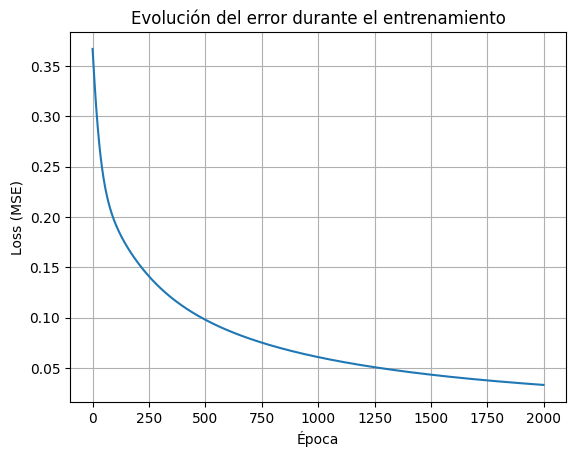

In [8]:
# 9. (Opcional) Graficamos la evolución del loss
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel('Época')
plt.ylabel('Loss (MSE)')
plt.title('Evolución del error durante el entrenamiento')
plt.grid(True)
plt.show()


Interpretación del gráfico:

- El eje X son las épocas.
- El eje Y es el error.
- Si la curva baja, significa que el perceptrón está aprendiendo.
